1. Data Exploration and Initial Insights

In [ ]:
import pandas as pd

# Load the CSV file into a DataFrame
st = pd.read_csv("/content/shopping_trends_updated.csv")

# Display the first few rows of the DataFrame
print(st.head)

<bound method NDFrame.head of       Customer ID  Age  Gender Item Purchased     Category  \
0               1   55    Male         Blouse     Clothing   
1               2   19    Male        Sweater     Clothing   
2               3   50    Male          Jeans     Clothing   
3               4   21    Male        Sandals     Footwear   
4               5   45    Male         Blouse     Clothing   
...           ...  ...     ...            ...          ...   
3895         3896   40  Female         Hoodie     Clothing   
3896         3897   52  Female       Backpack  Accessories   
3897         3898   46  Female           Belt  Accessories   
3898         3899   44  Female          Shoes     Footwear   
3899         3900   52  Female        Handbag  Accessories   

      Purchase Amount (USD)       Location Size      Color  Season  \
0                        53       Kentucky    L       Gray  Winter   
1                        64          Maine    L     Maroon  Winter   
2              

In [ ]:
print(st.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3900 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

2. Standardization and Clustering Analysis

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Ordinal columns
ordinal_columns = ['Size', 'Season', 'Subscription Status', 'Discount Applied', 'Promo Code Used']

# Label Encoding for ordinal columns
le = LabelEncoder()
for col in ordinal_columns:
    st[col] = le.fit_transform(st[col])

# Nominal columns
nominal_columns = ['Gender', 'Item Purchased', 'Category', 'Location', 'Color', 'Shipping Type', 'Payment Method', 'Frequency of Purchases']

# One-Hot Encoding for nominal columns without dropping the first category
st = pd.get_dummies(st, columns=nominal_columns)

# Convert boolean columns (True/False) to 1/0
st = st.astype(int)

# Show the updated dataframe
print(st.head())

   Customer ID  Age  Purchase Amount (USD)  Size  Season  Review Rating  \
0            1   55                     53     0       3              3   
1            2   19                     64     0       3              3   
2            3   50                     73     2       1              3   
3            4   21                     90     1       1              3   
4            5   45                     49     1       1              2   

   Subscription Status  Discount Applied  Promo Code Used  Previous Purchases  \
0                    1                 1                1                  14   
1                    1                 1                1                   2   
2                    1                 1                1                  23   
3                    1                 1                1                  49   
4                    1                 1                1                  31   

   Gender_Female  Gender_Male  Item Purchased_Backpack  Item P

In [ ]:
display(st)

,Customer ID,Age,Purchase Amount (USD),Size,Season,Review Rating,Subscription Status,Discount Applied,Promo Code Used,Previous Purchases,Gender_Female,Gender_Male,Item Purchased_Backpack,Item Purchased_Belt,Item Purchased_Blouse,Item Purchased_Boots,Item Purchased_Coat,Item Purchased_Dress,Item Purchased_Gloves,Item Purchased_Handbag,Item Purchased_Hat,Item Purchased_Hoodie,Item Purchased_Jacket,Item Purchased_Jeans,Item Purchased_Jewelry,Item Purchased_Pants,Item Purchased_Sandals,Item Purchased_Scarf,Item Purchased_Shirt,Item Purchased_Shoes,Item Purchased_Shorts,Item Purchased_Skirt,Item Purchased_Sneakers,Item Purchased_Socks,Item Purchased_Sunglasses,Item Purchased_Sweater,Item Purchased_T-shirt,Category_Accessories,Category_Clothing,Category_Footwear,Category_Outerwear,Location_Alabama,Location_Alaska,Location_Arizona,Location_Arkansas,Location_California,Location_Colorado,Location_Connecticut,Location_Delaware,Location_Florida,Location_Georgia,Location_Hawaii,Location_Idaho,Location_Illinois,Location_Indiana,Location_Iowa,Location_Kansas,Location_Kentucky,Location_Louisiana,Location_Maine,Location_Maryland,Location_Massachusetts,Location_Michigan,Location_Minnesota,Location_Mississippi,Location_Missouri,Location_Montana,Location_Nebraska,Location_Nevada,Location_New Hampshire,Location_New Jersey,Location_New Mexico,Location_New York,Location_North Carolina,Location_North Dakota,Location_Ohio,Location_Oklahoma,Location_Oregon,Location_Pennsylvania,Location_Rhode Island,Location_South Carolina,Location_South Dakota,Location_Tennessee,Location_Texas,Location_Utah,Location_Vermont,Location_Virginia,Location_Washington,Location_West Virginia,Location_Wisconsin,Location_Wyoming,Color_Beige,Color_Black,Color_Blue,Color_Brown,Color_Charcoal,Color_Cyan,Color_Gold,Color_Gray,Color_Green,Color_Indigo,Color_Lavender,Color_Magenta,Color_Maroon,Color_Olive,Color_Orange,Color_Peach,Color_Pink,Color_Purple,Color_Red,Color_Silver,Color_Teal,Color_Turquoise,Color_Violet,Color_White,Color_Yellow,Shipping Type_2-Day Shipping,Shipping Type_Express,Shipping Type_Free Shipping,Shipping Type_Next Day Air,Shipping Type_Standard,Shipping Type_Store Pickup,Payment Method_Bank Transfer,Payment Method_Cash,Payment Method_Credit Card,Payment Method_Debit Card,Payment Method_PayPal,Payment Method_Venmo,Frequency of Purchases_Annually,Frequency of Purchases_Bi-Weekly,Frequency of Purchases_Every 3 Months,Frequency of Purchases_Fortnightly,Frequency of Purchases_Monthly,Frequency of Purchases_Quarterly,Frequency of Purchases_Weekly
0,1,55,53,0,3,3,1,1,1,14,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0
1,2,19,64,0,3,3,1,1,1,2,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0
2,3,50,73,2,1,3,1,1,1,23,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1
3,4,21,90,1,1,3,1,1,1,49,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1
4,5,45,49,1,1,2,1,1,1,31,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,..

In [ ]:
import pandas as pd

# Set the option to display more columns
pd.set_option('display.max_columns', None)  # This will display all columns

# Now print the dataframe to see all columns
print(st.head())

   Customer ID  Age  Purchase Amount (USD)  Size  Season  Review Rating  \
0            1   55                     53     0       3              3   
1            2   19                     64     0       3              3   
2            3   50                     73     2       1              3   
3            4   21                     90     1       1              3   
4            5   45                     49     1       1              2   

   Subscription Status  Discount Applied  Promo Code Used  Previous Purchases  \
0                    1                 1                1                  14   
1                    1                 1                1                   2   
2                    1                 1                1                  23   
3                    1                 1                1                  49   
4                    1                 1                1                  31   

   Gender_Female  Gender_Male  Item Purchased_Backpack  Item P

In [ ]:
display(st)

,Customer ID,Age,Purchase Amount (USD),Size,Season,Review Rating,Subscription Status,Discount Applied,Promo Code Used,Previous Purchases,Gender_Female,Gender_Male,Item Purchased_Backpack,Item Purchased_Belt,Item Purchased_Blouse,Item Purchased_Boots,Item Purchased_Coat,Item Purchased_Dress,Item Purchased_Gloves,Item Purchased_Handbag,Item Purchased_Hat,Item Purchased_Hoodie,Item Purchased_Jacket,Item Purchased_Jeans,Item Purchased_Jewelry,Item Purchased_Pants,Item Purchased_Sandals,Item Purchased_Scarf,Item Purchased_Shirt,Item Purchased_Shoes,Item Purchased_Shorts,Item Purchased_Skirt,Item Purchased_Sneakers,Item Purchased_Socks,Item Purchased_Sunglasses,Item Purchased_Sweater,Item Purchased_T-shirt,Category_Accessories,Category_Clothing,Category_Footwear,Category_Outerwear,Location_Alabama,Location_Alaska,Location_Arizona,Location_Arkansas,Location_California,Location_Colorado,Location_Connecticut,Location_Delaware,Location_Florida,Location_Georgia,Location_Hawaii,Location_Idaho,Location_Illinois,Location_Indiana,Location_Iowa,Location_Kansas,Location_Kentucky,Location_Louisiana,Location_Maine,Location_Maryland,Location_Massachusetts,Location_Michigan,Location_Minnesota,Location_Mississippi,Location_Missouri,Location_Montana,Location_Nebraska,Location_Nevada,Location_New Hampshire,Location_New Jersey,Location_New Mexico,Location_New York,Location_North Carolina,Location_North Dakota,Location_Ohio,Location_Oklahoma,Location_Oregon,Location_Pennsylvania,Location_Rhode Island,Location_South Carolina,Location_South Dakota,Location_Tennessee,Location_Texas,Location_Utah,Location_Vermont,Location_Virginia,Location_Washington,Location_West Virginia,Location_Wisconsin,Location_Wyoming,Color_Beige,Color_Black,Color_Blue,Color_Brown,Color_Charcoal,Color_Cyan,Color_Gold,Color_Gray,Color_Green,Color_Indigo,Color_Lavender,Color_Magenta,Color_Maroon,Color_Olive,Color_Orange,Color_Peach,Color_Pink,Color_Purple,Color_Red,Color_Silver,Color_Teal,Color_Turquoise,Color_Violet,Color_White,Color_Yellow,Shipping Type_2-Day Shipping,Shipping Type_Express,Shipping Type_Free Shipping,Shipping Type_Next Day Air,Shipping Type_Standard,Shipping Type_Store Pickup,Payment Method_Bank Transfer,Payment Method_Cash,Payment Method_Credit Card,Payment Method_Debit Card,Payment Method_PayPal,Payment Method_Venmo,Frequency of Purchases_Annually,Frequency of Purchases_Bi-Weekly,Frequency of Purchases_Every 3 Months,Frequency of Purchases_Fortnightly,Frequency of Purchases_Monthly,Frequency of Purchases_Quarterly,Frequency of Purchases_Weekly
0,1,55,53,0,3,3,1,1,1,14,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0
1,2,19,64,0,3,3,1,1,1,2,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0
2,3,50,73,2,1,3,1,1,1,23,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1
3,4,21,90,1,1,3,1,1,1,49,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1
4,5,45,49,1,1,2,1,1,1,31,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,..

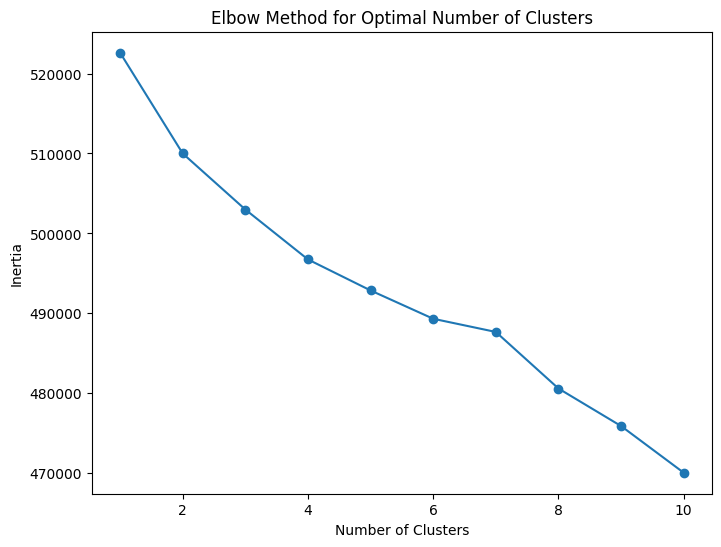

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Assuming 'st' is your dataframe after encoding

# Step 1: Scale the data (excluding the Customer ID as it's not a feature)
features = st.drop(columns=['Customer ID'])  # Exclude Customer ID if it's not a feature

# Standardize the data
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# Step 2: Apply K-Means clustering
# Elbow Method to find the optimal number of clusters
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

# Plot the Elbow graph
plt.figure(figsize=(8, 6))
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method for Optimal Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Assuming 'st' is your dataframe after encoding

# Step 1: Scale the data (excluding the Customer ID as it's not a feature)
features = st.drop(columns=['Customer ID'])  # Exclude Customer ID if it's not a feature

# Standardize the data
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# Step 2: Apply K-Means clustering with 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42)
st['Cluster'] = kmeans.fit_predict(scaled_features)

# Show the dataframe with the assigned clusters
print(st.head())

   Customer ID  Age  Purchase Amount (USD)  Size  Season  Review Rating  \
0            1   55                     53     0       3              3   
1            2   19                     64     0       3              3   
2            3   50                     73     2       1              3   
3            4   21                     90     1       1              3   
4            5   45                     49     1       1              2   

   Subscription Status  Discount Applied  Promo Code Used  Previous Purchases  \
0                    1                 1                1                  14   
1                    1                 1                1                   2   
2                    1                 1                1                  23   
3                    1                 1                1                  49   
4                    1                 1                1                  31   

   Gender_Female  Gender_Male  Item Purchased_Backpack  Item P

3. Conducting Principal Component Analysis (PCA) and Visualization

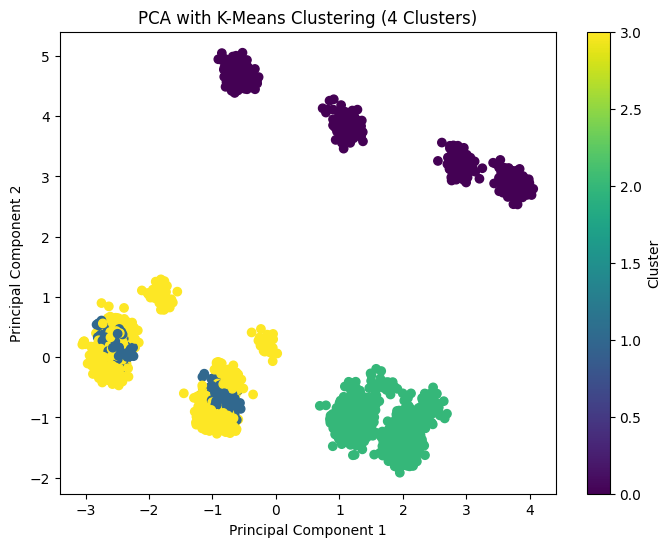

         Customer ID        Age  Purchase Amount (USD)      Size    Season  \
Cluster                                                                      
0        1959.759599  44.442404              60.255426  1.091820  1.507513   
1        2795.757532  44.212339              60.889527  1.156385  1.480631   
2         839.770804  44.150212              58.818759  1.141749  1.523272   
3        2777.079258  43.697302              59.985666  1.086847  1.456155   

         Review Rating  Subscription Status  Discount Applied  \
Cluster                                                         
0             3.302170             0.285476          0.432387   
1             3.289813             0.000000          0.000000   
2             3.245416             0.622003          1.000000   
3             3.249578             0.000000          0.000000   

         Promo Code Used  Previous Purchases  Gender_Female  Gender_Male  \
Cluster                                                         

In [ ]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Assuming 'st' is your dataframe after encoding

# Step 1: Scale the data (excluding the Customer ID as it's not a feature)
features = st.drop(columns=['Customer ID'])  # Exclude Customer ID if it's not a feature

# Standardize the data
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# Step 2: Apply K-Means clustering with 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42)
st['Cluster'] = kmeans.fit_predict(scaled_features)

# Step 3: Apply PCA to reduce dimensions (to 2 components for visualization)
pca = PCA(n_components=2)
principal_components = pca.fit_transform(scaled_features)

# Add the PCA results to the dataframe
st['PCA1'] = principal_components[:, 0]
st['PCA2'] = principal_components[:, 1]

# Step 4: Visualize the results of the PCA with respect to the clusters
plt.figure(figsize=(8, 6))
plt.scatter(st['PCA1'], st['PCA2'], c=st['Cluster'], cmap='viridis')
plt.title('PCA with K-Means Clustering (4 Clusters)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='Cluster')
plt.show()

# Step 5: Show the mean for each category (grouped by 'Cluster')
category_means = st.groupby('Cluster').mean()

# Display the means for each cluster
print(category_means)

In [ ]:
display(st)

,Customer ID,Age,Purchase Amount (USD),Size,Season,Review Rating,Subscription Status,Discount Applied,Promo Code Used,Previous Purchases,Gender_Female,Gender_Male,Item Purchased_Backpack,Item Purchased_Belt,Item Purchased_Blouse,Item Purchased_Boots,Item Purchased_Coat,Item Purchased_Dress,Item Purchased_Gloves,Item Purchased_Handbag,Item Purchased_Hat,Item Purchased_Hoodie,Item Purchased_Jacket,Item Purchased_Jeans,Item Purchased_Jewelry,Item Purchased_Pants,Item Purchased_Sandals,Item Purchased_Scarf,Item Purchased_Shirt,Item Purchased_Shoes,Item Purchased_Shorts,Item Purchased_Skirt,Item Purchased_Sneakers,Item Purchased_Socks,Item Purchased_Sunglasses,Item Purchased_Sweater,Item Purchased_T-shirt,Category_Accessories,Category_Clothing,Category_Footwear,Category_Outerwear,Location_Alabama,Location_Alaska,Location_Arizona,Location_Arkansas,Location_California,Location_Colorado,Location_Connecticut,Location_Delaware,Location_Florida,Location_Georgia,Location_Hawaii,Location_Idaho,Location_Illinois,Location_Indiana,Location_Iowa,Location_Kansas,Location_Kentucky,Location_Louisiana,Location_Maine,Location_Maryland,Location_Massachusetts,Location_Michigan,Location_Minnesota,Location_Mississippi,Location_Missouri,Location_Montana,Location_Nebraska,Location_Nevada,Location_New Hampshire,Location_New Jersey,Location_New Mexico,Location_New York,Location_North Carolina,Location_North Dakota,Location_Ohio,Location_Oklahoma,Location_Oregon,Location_Pennsylvania,Location_Rhode Island,Location_South Carolina,Location_South Dakota,Location_Tennessee,Location_Texas,Location_Utah,Location_Vermont,Location_Virginia,Location_Washington,Location_West Virginia,Location_Wisconsin,Location_Wyoming,Color_Beige,Color_Black,Color_Blue,Color_Brown,Color_Charcoal,Color_Cyan,Color_Gold,Color_Gray,Color_Green,Color_Indigo,Color_Lavender,Color_Magenta,Color_Maroon,Color_Olive,Color_Orange,Color_Peach,Color_Pink,Color_Purple,Color_Red,Color_Silver,Color_Teal,Color_Turquoise,Color_Violet,Color_White,Color_Yellow,Shipping Type_2-Day Shipping,Shipping Type_Express,Shipping Type_Free Shipping,Shipping Type_Next Day Air,Shipping Type_Standard,Shipping Type_Store Pickup,Payment Method_Bank Transfer,Payment Method_Cash,Payment Method_Credit Card,Payment Method_Debit Card,Payment Method_PayPal,Payment Method_Venmo,Frequency of Purchases_Annually,Frequency of Purchases_Bi-Weekly,Frequency of Purchases_Every 3 Months,Frequency of Purchases_Fortnightly,Frequency of Purchases_Monthly,Frequency of Purchases_Quarterly,Frequency of Purchases_Weekly,Cluster,PCA1,PCA2,Cluster_Label
0,1,55,53,0,3,3,1,1,1,14,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,2,2.275052,-1.617282,"Promo-Driven Generalists (Male only, wide prod..."
1,2,19,64,0,3,3,1,1,1,2,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,2,2.381486,-1.417368,"Promo-Driven Generalists (Male only, wide prod..."
2,3,50,73,2,1,3,1,1,1,23,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,2,2.527105,-1.540520,"Promo-Driven Generalists (Male only, wide prod..."
3,4,21,90,1,1,3,1,1,1,49,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,3.020303,3.786473,Footwear Focused Shoppers
4,5,45,49,1,1,2,1,1,1,31,0,1,0,0,1,0,0,0,0,0,0,0,0,0

4. Summary of Analysis Steps and Results

                                            Age  Purchase Amount (USD)  \
Cluster_Label                                                            
Accessory Enthusiasts                 44.212339              60.889527   
Clothing and Outerwear Enthusiasts    43.697302              59.985666   
Footwear Focused Shoppers             44.442404              60.255426   
Promo-Driven Generalists (Male only)  44.150212              58.818759   

                                          Size    Season  Review Rating  \
Cluster_Label                                                             
Accessory Enthusiasts                 1.156385  1.480631       3.289813   
Clothing and Outerwear Enthusiasts    1.086847  1.456155       3.249578   
Footwear Focused Shoppers             1.091820  1.507513       3.302170   
Promo-Driven Generalists (Male only)  1.141749  1.523272       3.245416   

                                      Subscription Status  Discount Applied  \
Cluster_Label            

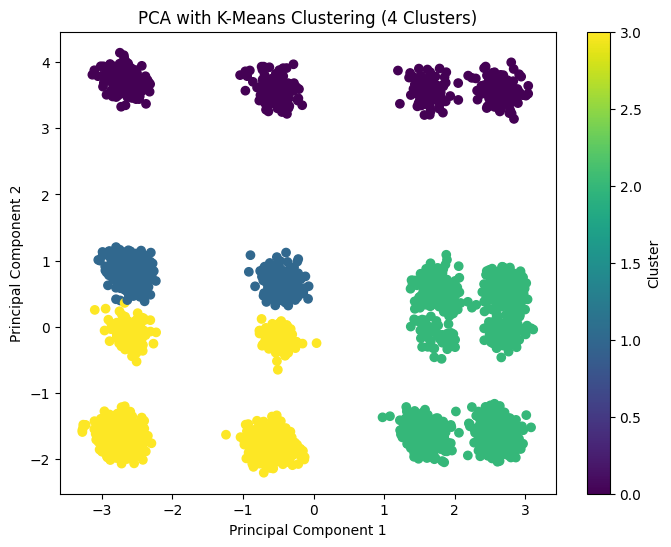

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Assuming 'st' is your dataframe after encoding

# Step 1: Scale the data (excluding the Customer ID as it's not a feature)
# Select only numerical columns for scaling
numerical_columns = st.select_dtypes(include=['float64', 'int64']).columns.drop('Customer ID')
features = st[numerical_columns]

# Standardize the data
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# Step 2: Apply K-Means clustering with 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42)
st['Cluster'] = kmeans.fit_predict(scaled_features)

# Step 3: Apply PCA to reduce dimensions (to 2 components for visualization)
pca = PCA(n_components=2)
principal_components = pca.fit_transform(scaled_features)

# Step 4: Visualize the results of the PCA with respect to the clusters
plt.figure(figsize=(8, 6))
scatter = plt.scatter(principal_components[:, 0], principal_components[:, 1], c=st['Cluster'], cmap='viridis')
plt.title('PCA with K-Means Clustering (4 Clusters)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(scatter, label='Cluster')

# Define custom labels for each cluster
cluster_labels = {
    0: "Footwear Focused Shoppers",
    1: "Accessory Enthusiasts",
    2: "Promo-Driven Generalists (Male only)",
    3: "Clothing and Outerwear Enthusiasts"
}

# Add cluster labels to the dataframe 'st'
st['Cluster_Label'] = st['Cluster'].map(cluster_labels)

# Step 5: Show the mean for each category (grouped by 'Cluster_Label')
category_means = st.groupby('Cluster_Label')[numerical_columns].mean()

# Display the means for each cluster
print(category_means)

In [ ]:
display(st)

,Customer ID,Age,Purchase Amount (USD),Size,Season,Review Rating,Subscription Status,Discount Applied,Promo Code Used,Previous Purchases,Gender_Female,Gender_Male,Item Purchased_Backpack,Item Purchased_Belt,Item Purchased_Blouse,Item Purchased_Boots,Item Purchased_Coat,Item Purchased_Dress,Item Purchased_Gloves,Item Purchased_Handbag,Item Purchased_Hat,Item Purchased_Hoodie,Item Purchased_Jacket,Item Purchased_Jeans,Item Purchased_Jewelry,Item Purchased_Pants,Item Purchased_Sandals,Item Purchased_Scarf,Item Purchased_Shirt,Item Purchased_Shoes,Item Purchased_Shorts,Item Purchased_Skirt,Item Purchased_Sneakers,Item Purchased_Socks,Item Purchased_Sunglasses,Item Purchased_Sweater,Item Purchased_T-shirt,Category_Accessories,Category_Clothing,Category_Footwear,Category_Outerwear,Location_Alabama,Location_Alaska,Location_Arizona,Location_Arkansas,Location_California,Location_Colorado,Location_Connecticut,Location_Delaware,Location_Florida,Location_Georgia,Location_Hawaii,Location_Idaho,Location_Illinois,Location_Indiana,Location_Iowa,Location_Kansas,Location_Kentucky,Location_Louisiana,Location_Maine,Location_Maryland,Location_Massachusetts,Location_Michigan,Location_Minnesota,Location_Mississippi,Location_Missouri,Location_Montana,Location_Nebraska,Location_Nevada,Location_New Hampshire,Location_New Jersey,Location_New Mexico,Location_New York,Location_North Carolina,Location_North Dakota,Location_Ohio,Location_Oklahoma,Location_Oregon,Location_Pennsylvania,Location_Rhode Island,Location_South Carolina,Location_South Dakota,Location_Tennessee,Location_Texas,Location_Utah,Location_Vermont,Location_Virginia,Location_Washington,Location_West Virginia,Location_Wisconsin,Location_Wyoming,Color_Beige,Color_Black,Color_Blue,Color_Brown,Color_Charcoal,Color_Cyan,Color_Gold,Color_Gray,Color_Green,Color_Indigo,Color_Lavender,Color_Magenta,Color_Maroon,Color_Olive,Color_Orange,Color_Peach,Color_Pink,Color_Purple,Color_Red,Color_Silver,Color_Teal,Color_Turquoise,Color_Violet,Color_White,Color_Yellow,Shipping Type_2-Day Shipping,Shipping Type_Express,Shipping Type_Free Shipping,Shipping Type_Next Day Air,Shipping Type_Standard,Shipping Type_Store Pickup,Payment Method_Bank Transfer,Payment Method_Cash,Payment Method_Credit Card,Payment Method_Debit Card,Payment Method_PayPal,Payment Method_Venmo,Frequency of Purchases_Annually,Frequency of Purchases_Bi-Weekly,Frequency of Purchases_Every 3 Months,Frequency of Purchases_Fortnightly,Frequency of Purchases_Monthly,Frequency of Purchases_Quarterly,Frequency of Purchases_Weekly,Cluster,PCA1,PCA2,Cluster_Label
0,1,55,53,0,3,3,1,1,1,14,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,2,2.275052,-1.617282,Promo-Driven Generalists (Male only)
1,2,19,64,0,3,3,1,1,1,2,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,2,2.381486,-1.417368,Promo-Driven Generalists (Male only)
2,3,50,73,2,1,3,1,1,1,23,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,2,2.527105,-1.540520,Promo-Driven Generalists (Male only)
3,4,21,90,1,1,3,1,1,1,49,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,3.020303,3.786473,Footwear Focused Shoppers
4,5,45,49,1,1,2,1,1,1,31,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,

In [ ]:
import pandas as pd

# Assuming 'st' is your DataFrame
# Display the DataFrame (optional)
print(st)

# Remove the columns 'PCA1' and 'PCA2'
st = st.drop(columns=['PCA1', 'PCA2'])

# Display the updated DataFrame to confirm removal
print(st)

      Customer ID  Age  Purchase Amount (USD)  Size  Season  Review Rating  \
0               1   55                     53     0       3              3   
1               2   19                     64     0       3              3   
2               3   50                     73     2       1              3   
3               4   21                     90     1       1              3   
4               5   45                     49     1       1              2   
...           ...  ...                    ...   ...     ...            ...   
3895         3896   40                     28     0       2              4   
3896         3897   52                     49     0       1              4   
3897         3898   46                     33     0       1              2   
3898         3899   44                     77     2       2              3   
3899         3900   52                     81     1       1              3   

      Subscription Status  Discount Applied  Promo Code Used  \

In [ ]:
display(st)

,Customer ID,Age,Purchase Amount (USD),Size,Season,Review Rating,Subscription Status,Discount Applied,Promo Code Used,Previous Purchases,Gender_Female,Gender_Male,Item Purchased_Backpack,Item Purchased_Belt,Item Purchased_Blouse,Item Purchased_Boots,Item Purchased_Coat,Item Purchased_Dress,Item Purchased_Gloves,Item Purchased_Handbag,Item Purchased_Hat,Item Purchased_Hoodie,Item Purchased_Jacket,Item Purchased_Jeans,Item Purchased_Jewelry,Item Purchased_Pants,Item Purchased_Sandals,Item Purchased_Scarf,Item Purchased_Shirt,Item Purchased_Shoes,Item Purchased_Shorts,Item Purchased_Skirt,Item Purchased_Sneakers,Item Purchased_Socks,Item Purchased_Sunglasses,Item Purchased_Sweater,Item Purchased_T-shirt,Category_Accessories,Category_Clothing,Category_Footwear,Category_Outerwear,Location_Alabama,Location_Alaska,Location_Arizona,Location_Arkansas,Location_California,Location_Colorado,Location_Connecticut,Location_Delaware,Location_Florida,Location_Georgia,Location_Hawaii,Location_Idaho,Location_Illinois,Location_Indiana,Location_Iowa,Location_Kansas,Location_Kentucky,Location_Louisiana,Location_Maine,Location_Maryland,Location_Massachusetts,Location_Michigan,Location_Minnesota,Location_Mississippi,Location_Missouri,Location_Montana,Location_Nebraska,Location_Nevada,Location_New Hampshire,Location_New Jersey,Location_New Mexico,Location_New York,Location_North Carolina,Location_North Dakota,Location_Ohio,Location_Oklahoma,Location_Oregon,Location_Pennsylvania,Location_Rhode Island,Location_South Carolina,Location_South Dakota,Location_Tennessee,Location_Texas,Location_Utah,Location_Vermont,Location_Virginia,Location_Washington,Location_West Virginia,Location_Wisconsin,Location_Wyoming,Color_Beige,Color_Black,Color_Blue,Color_Brown,Color_Charcoal,Color_Cyan,Color_Gold,Color_Gray,Color_Green,Color_Indigo,Color_Lavender,Color_Magenta,Color_Maroon,Color_Olive,Color_Orange,Color_Peach,Color_Pink,Color_Purple,Color_Red,Color_Silver,Color_Teal,Color_Turquoise,Color_Violet,Color_White,Color_Yellow,Shipping Type_2-Day Shipping,Shipping Type_Express,Shipping Type_Free Shipping,Shipping Type_Next Day Air,Shipping Type_Standard,Shipping Type_Store Pickup,Payment Method_Bank Transfer,Payment Method_Cash,Payment Method_Credit Card,Payment Method_Debit Card,Payment Method_PayPal,Payment Method_Venmo,Frequency of Purchases_Annually,Frequency of Purchases_Bi-Weekly,Frequency of Purchases_Every 3 Months,Frequency of Purchases_Fortnightly,Frequency of Purchases_Monthly,Frequency of Purchases_Quarterly,Frequency of Purchases_Weekly,Cluster,Cluster_Label
0,1,55,53,0,3,3,1,1,1,14,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,2,Promo-Driven Generalists (Male only)
1,2,19,64,0,3,3,1,1,1,2,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,2,Promo-Driven Generalists (Male only)
2,3,50,73,2,1,3,1,1,1,23,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,2,Promo-Driven Generalists (Male only)
3,4,21,90,1,1,3,1,1,1,49,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,Footwear Focused Shoppers
4,5,45,49,1,1,2,1,1,1,31,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0

In [ ]:
import pandas as pd

# Load the CSV file into a DataFrame
st2 = pd.read_csv("/content/shopping_trends_updated.csv")

# Display the first few rows of the DataFrame
print(st2.head)

<bound method NDFrame.head of       Customer ID  Age  Gender Item Purchased     Category  \
0               1   55    Male         Blouse     Clothing   
1               2   19    Male        Sweater     Clothing   
2               3   50    Male          Jeans     Clothing   
3               4   21    Male        Sandals     Footwear   
4               5   45    Male         Blouse     Clothing   
...           ...  ...     ...            ...          ...   
3895         3896   40  Female         Hoodie     Clothing   
3896         3897   52  Female       Backpack  Accessories   
3897         3898   46  Female           Belt  Accessories   
3898         3899   44  Female          Shoes     Footwear   
3899         3900   52  Female        Handbag  Accessories   

      Purchase Amount (USD)       Location Size      Color  Season  \
0                        53       Kentucky    L       Gray  Winter   
1                        64          Maine    L     Maroon  Winter   
2              

In [ ]:
import pandas as pd

# Load the CSV file into a DataFrame (st2 is the original dataset)
st2 = pd.read_csv("/content/shopping_trends_updated.csv")

# Assuming that 'st' contains the 'Cluster' and 'Cluster_Label' columns
# Merge st2 with st based on a common identifier, e.g., 'Customer ID'
# If 'Customer ID' is the identifier column in both datasets
st2 = st2.merge(st[['Customer ID', 'Cluster', 'Cluster_Label']], on='Customer ID', how='left')

# Display the first few rows of the updated DataFrame
print(st2.head())

   Customer ID  Age Gender Item Purchased  Category  Purchase Amount (USD)  \
0            1   55   Male         Blouse  Clothing                     53   
1            2   19   Male        Sweater  Clothing                     64   
2            3   50   Male          Jeans  Clothing                     73   
3            4   21   Male        Sandals  Footwear                     90   
4            5   45   Male         Blouse  Clothing                     49   

        Location Size      Color  Season  Review Rating Subscription Status  \
0       Kentucky    L       Gray  Winter            3.1                 Yes   
1          Maine    L     Maroon  Winter            3.1                 Yes   
2  Massachusetts    S     Maroon  Spring            3.1                 Yes   
3   Rhode Island    M     Maroon  Spring            3.5                 Yes   
4         Oregon    M  Turquoise  Spring            2.7                 Yes   

   Shipping Type Discount Applied Promo Code Used  Previ

In [ ]:
# Save the updated st2 dataframe as a CSV file
st2.to_csv("/content/shopping_trends_updated_with_clusters.csv", index=False)

# Confirm the file has been saved
print("File saved as 'shopping_trends_updated_with_clusters.csv'")

File saved as 'shopping_trends_updated_with_clusters.csv'


In [ ]:
print(st2.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3900 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   